# 05b - Stacked Bars (Budget by Height)
Run `05-00-shared-data.ipynb` first to load data.

In [ ]:
%run 05-00-shared-data.ipynb
from utilities.style_profiles import apply_publication_style, save_fig, SINGLE_COL_IN, FULL_COL_IN, MAX_H_IN, MM, PROC_COLORS, proc_color, ENERGY_PROCESSES, HEAT_RELEASE_PROCESSES, HEAT_CONSUME_PROCESSES
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
apply_publication_style()

---
## View B – Stacked bar charts: process budget by height level

Time-averaged absolute rates per process at each height level.
Left panel = sources, right panel = sinks.

**What this view shows:** View B shows the same process tendency terms averaged over **time** and plotted as stacked bars by **height**. So you see which processes dominate at which levels. The same interpretation applies: for ice number, CONDNFROD is redistribution only (exclude from total number growth); for ice mass, condensation is growth+shift.

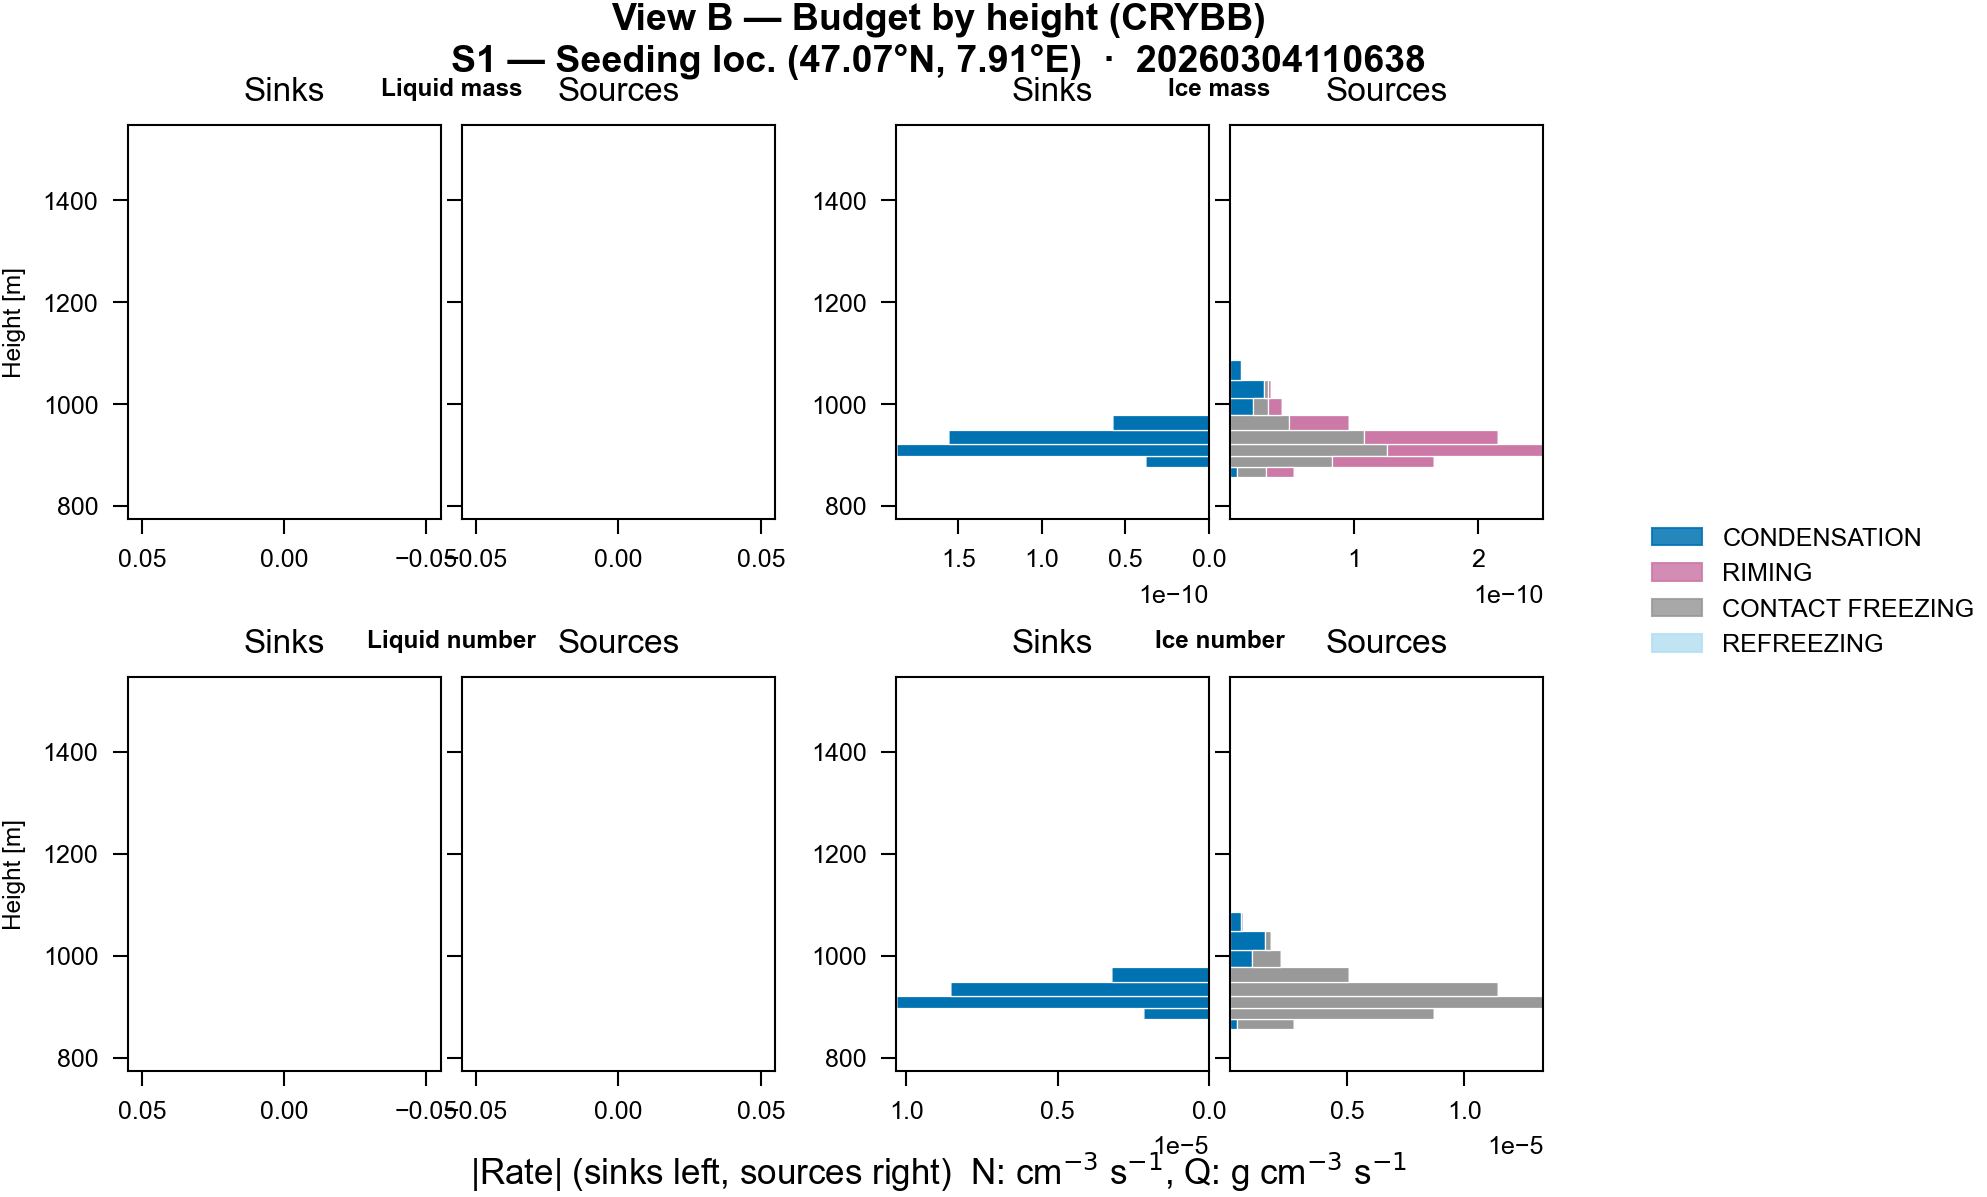

saved → ./stacked_bars_height_liquid_ice_exp1_stn0_CRYBB.png


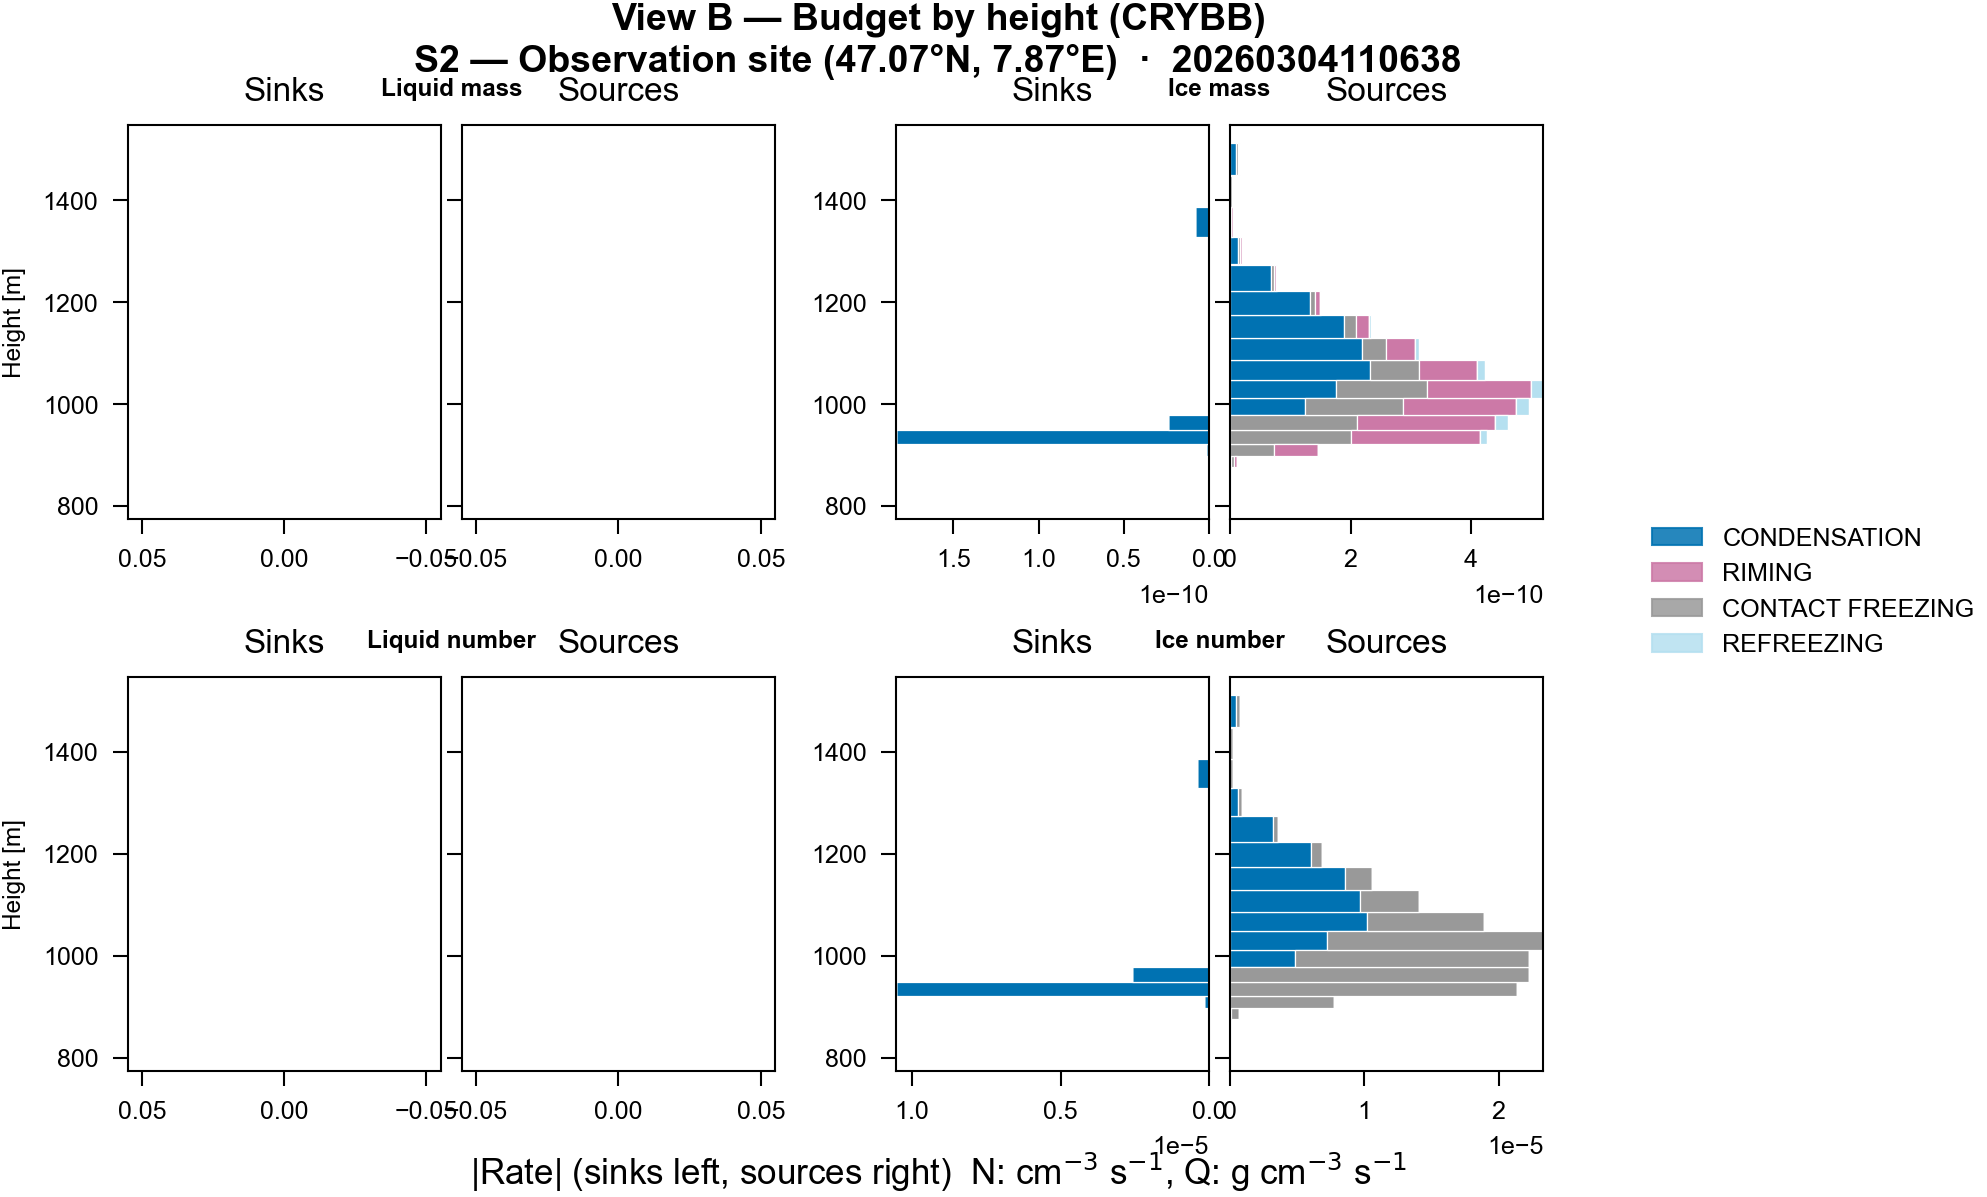

saved → ./stacked_bars_height_liquid_ice_exp1_stn1_CRYBB.png


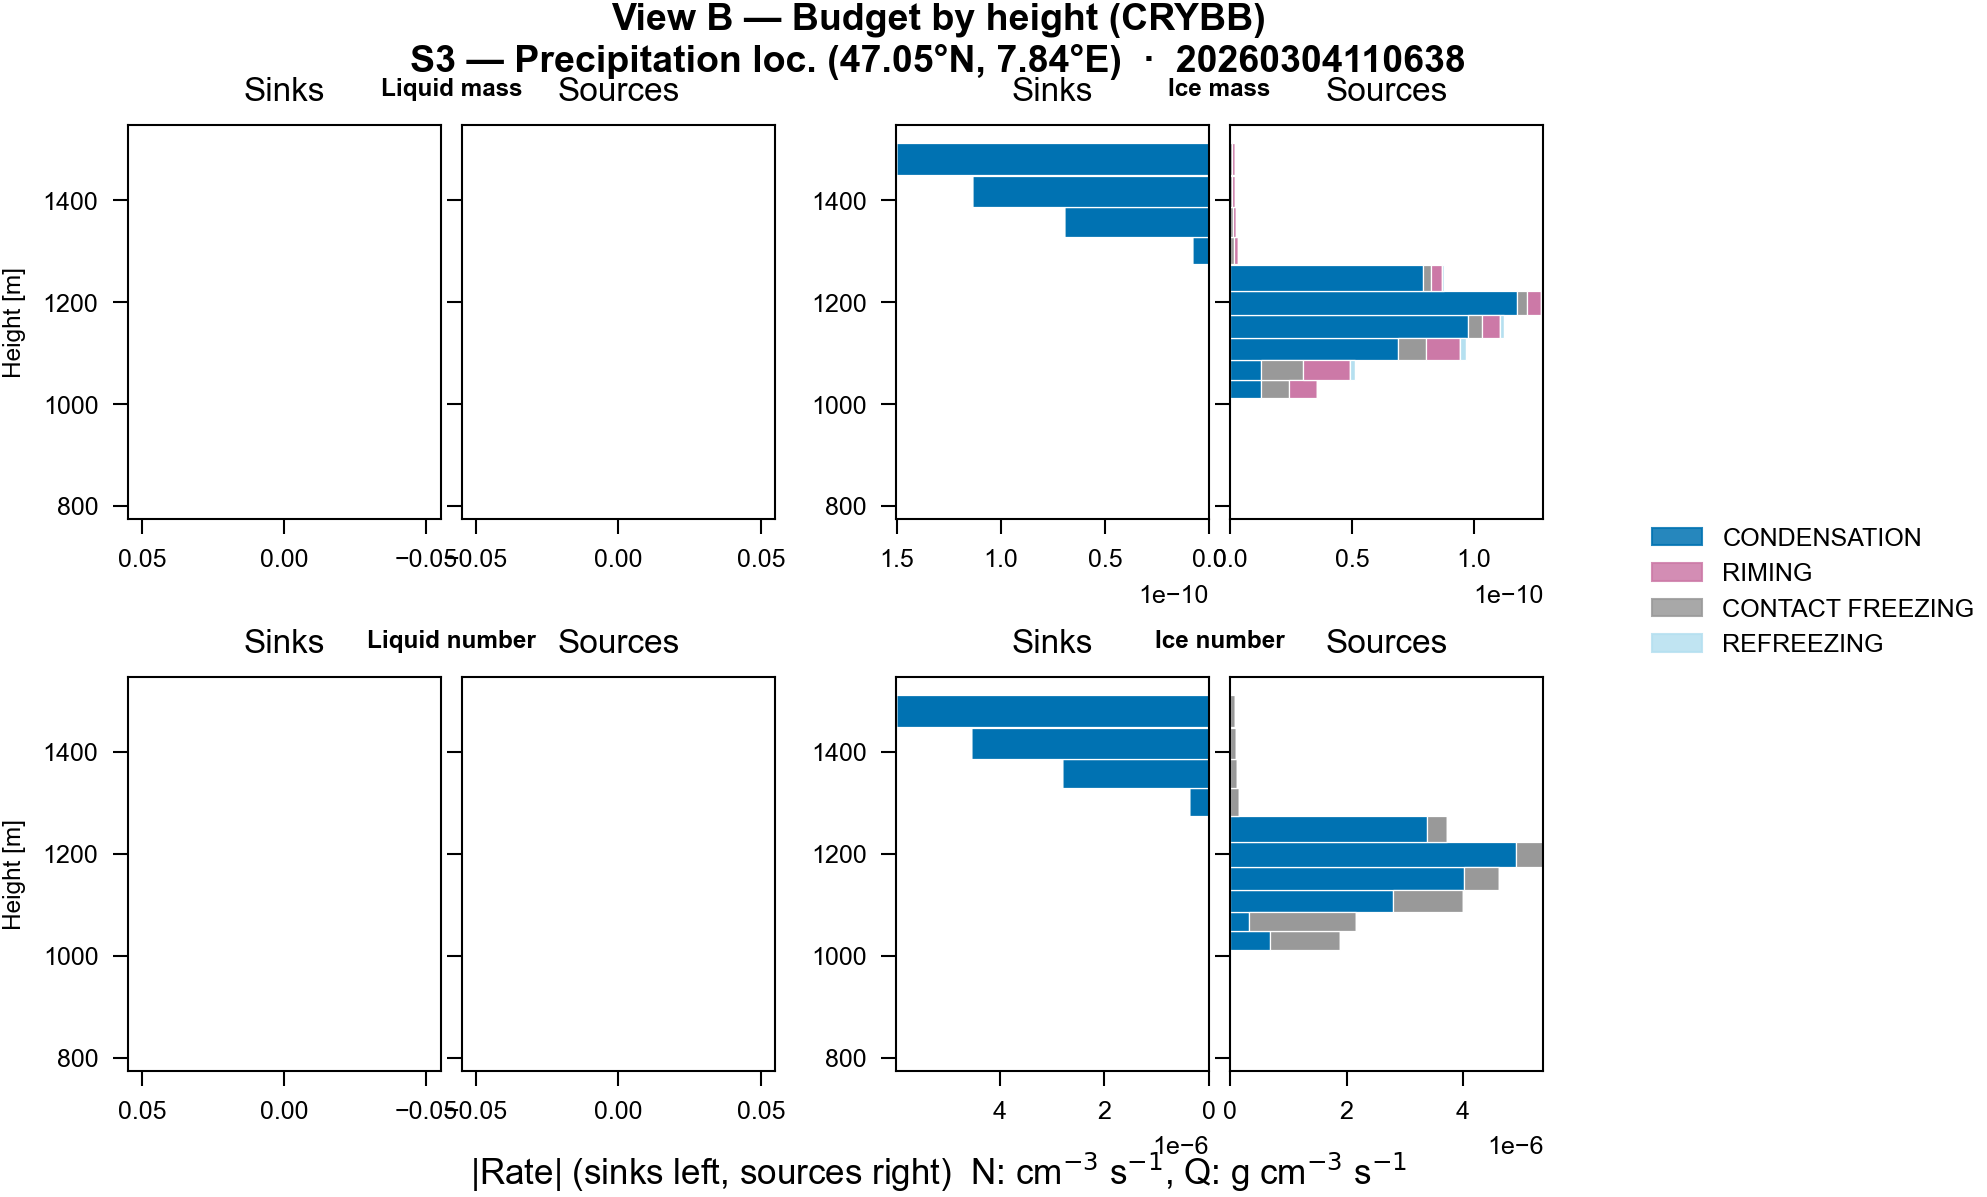

saved → ./stacked_bars_height_liquid_ice_exp1_stn2_CRYBB.png


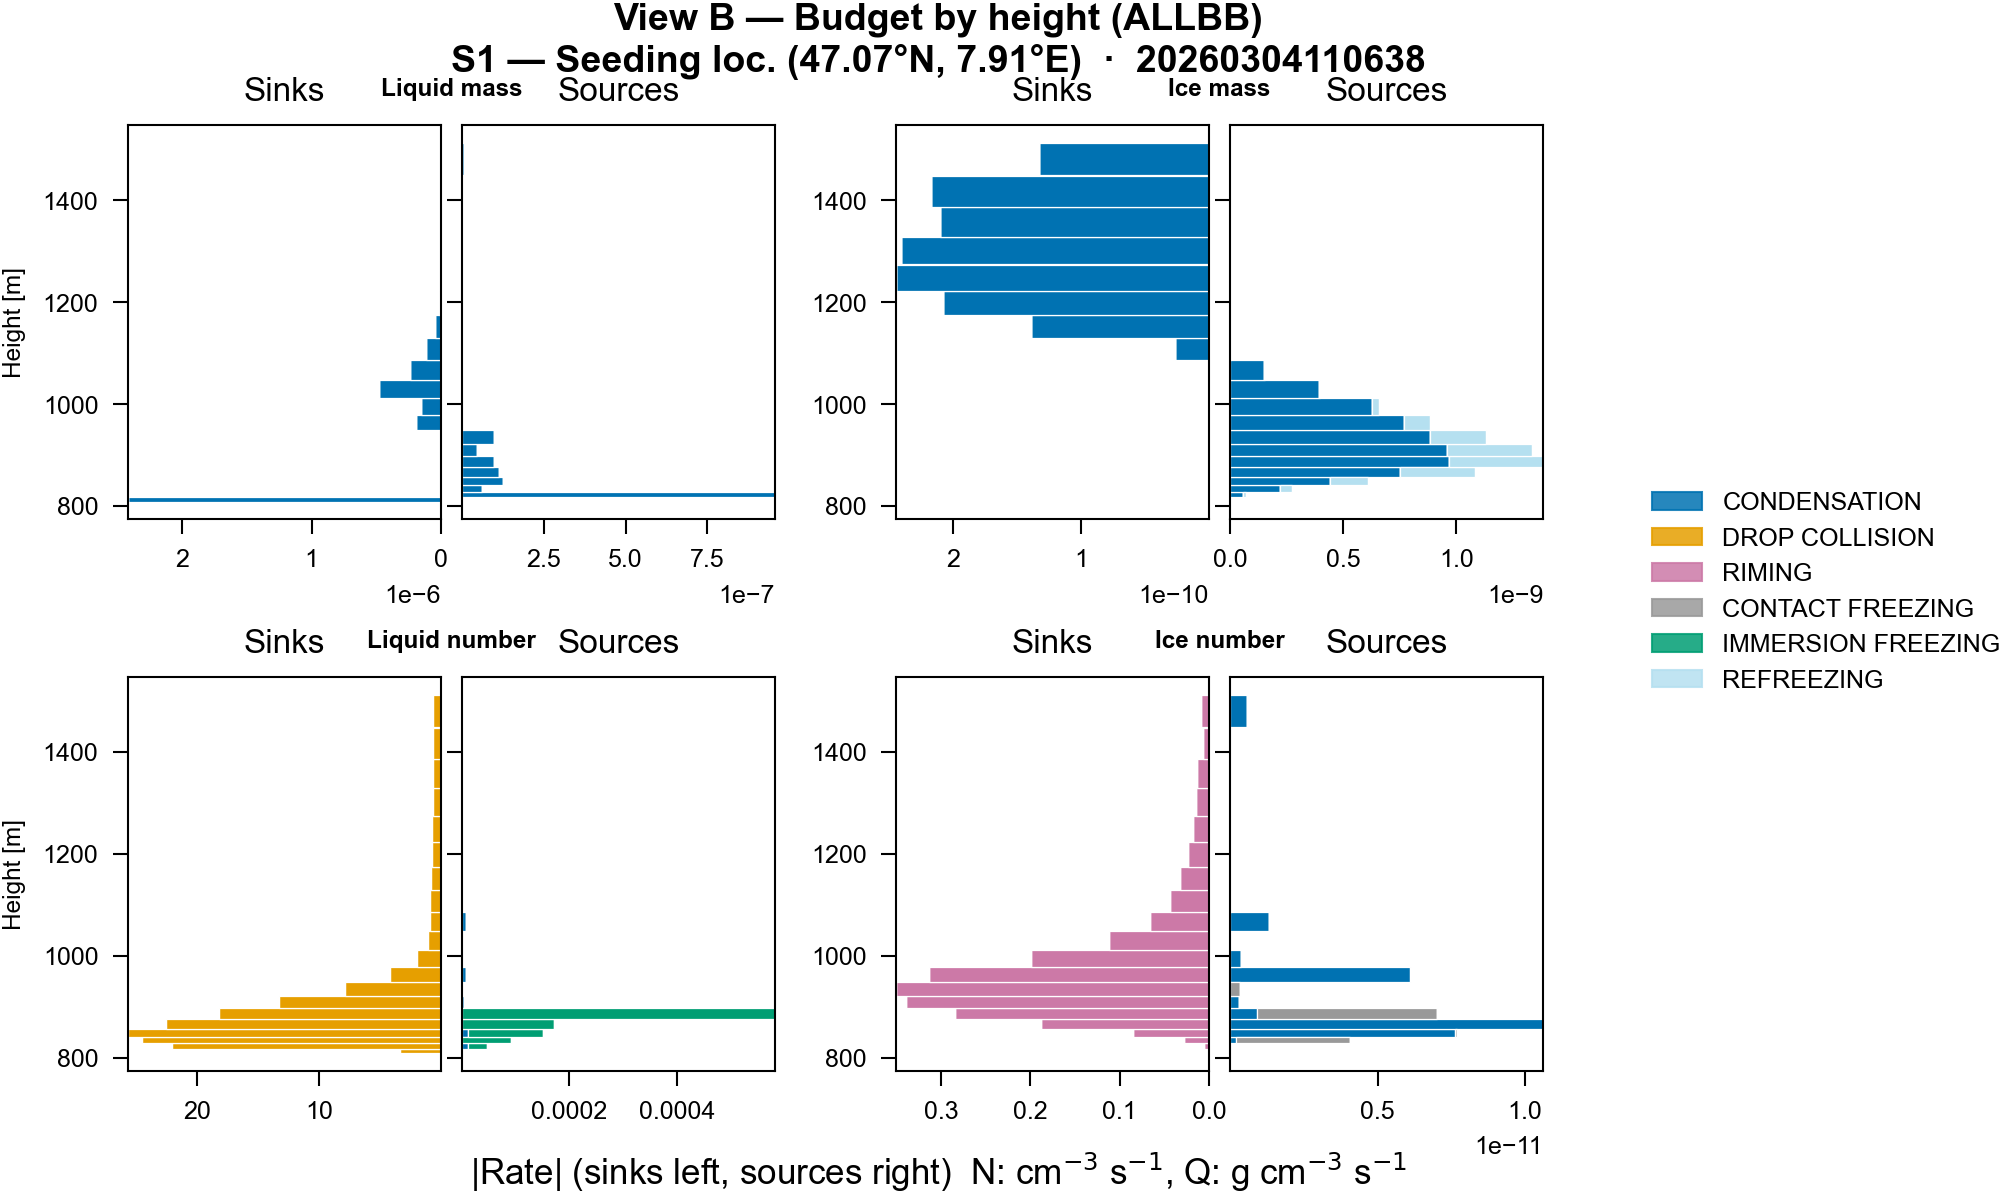

saved → ./stacked_bars_height_liquid_ice_exp1_stn0_ALLBB.png


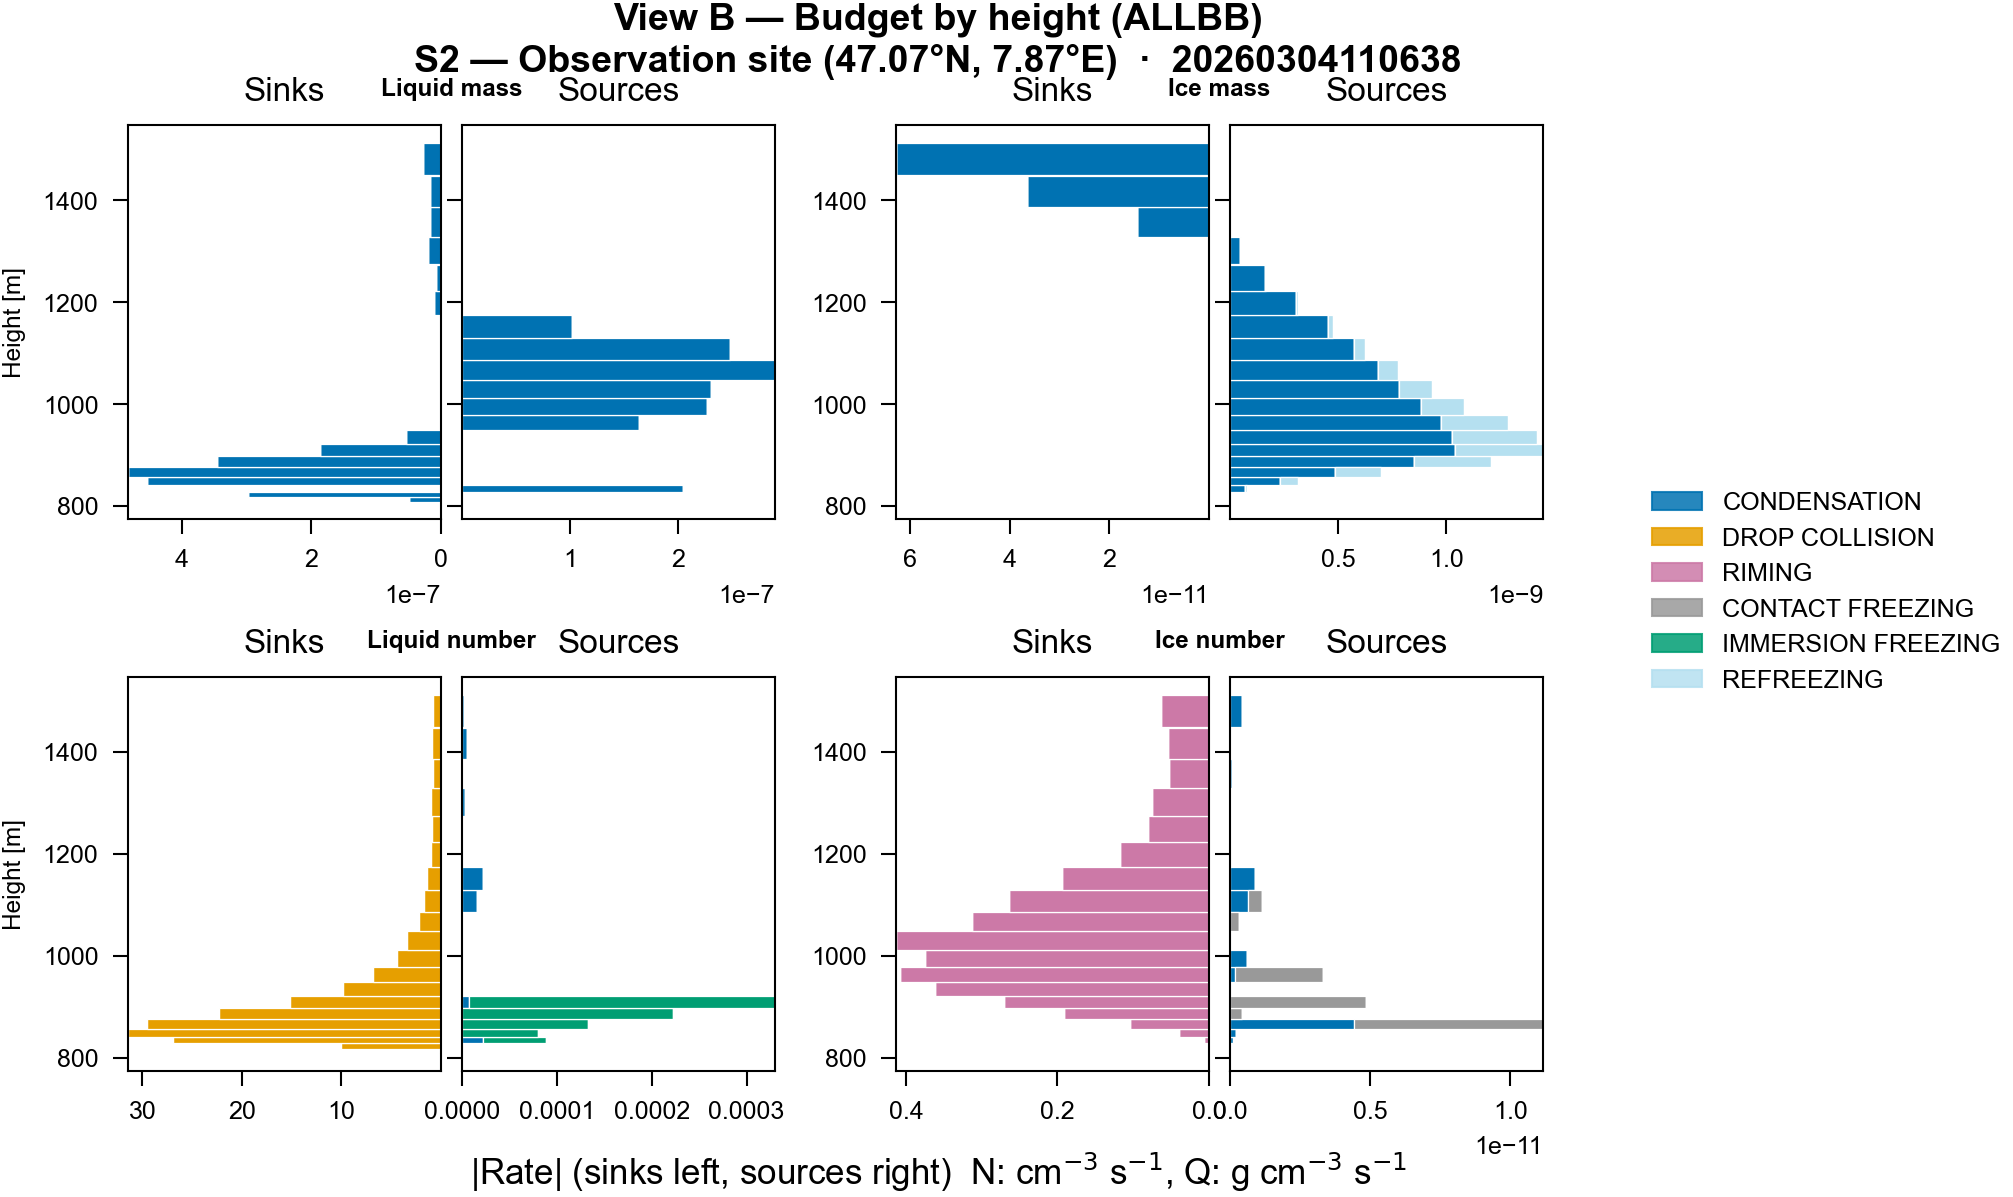

saved → ./stacked_bars_height_liquid_ice_exp1_stn1_ALLBB.png


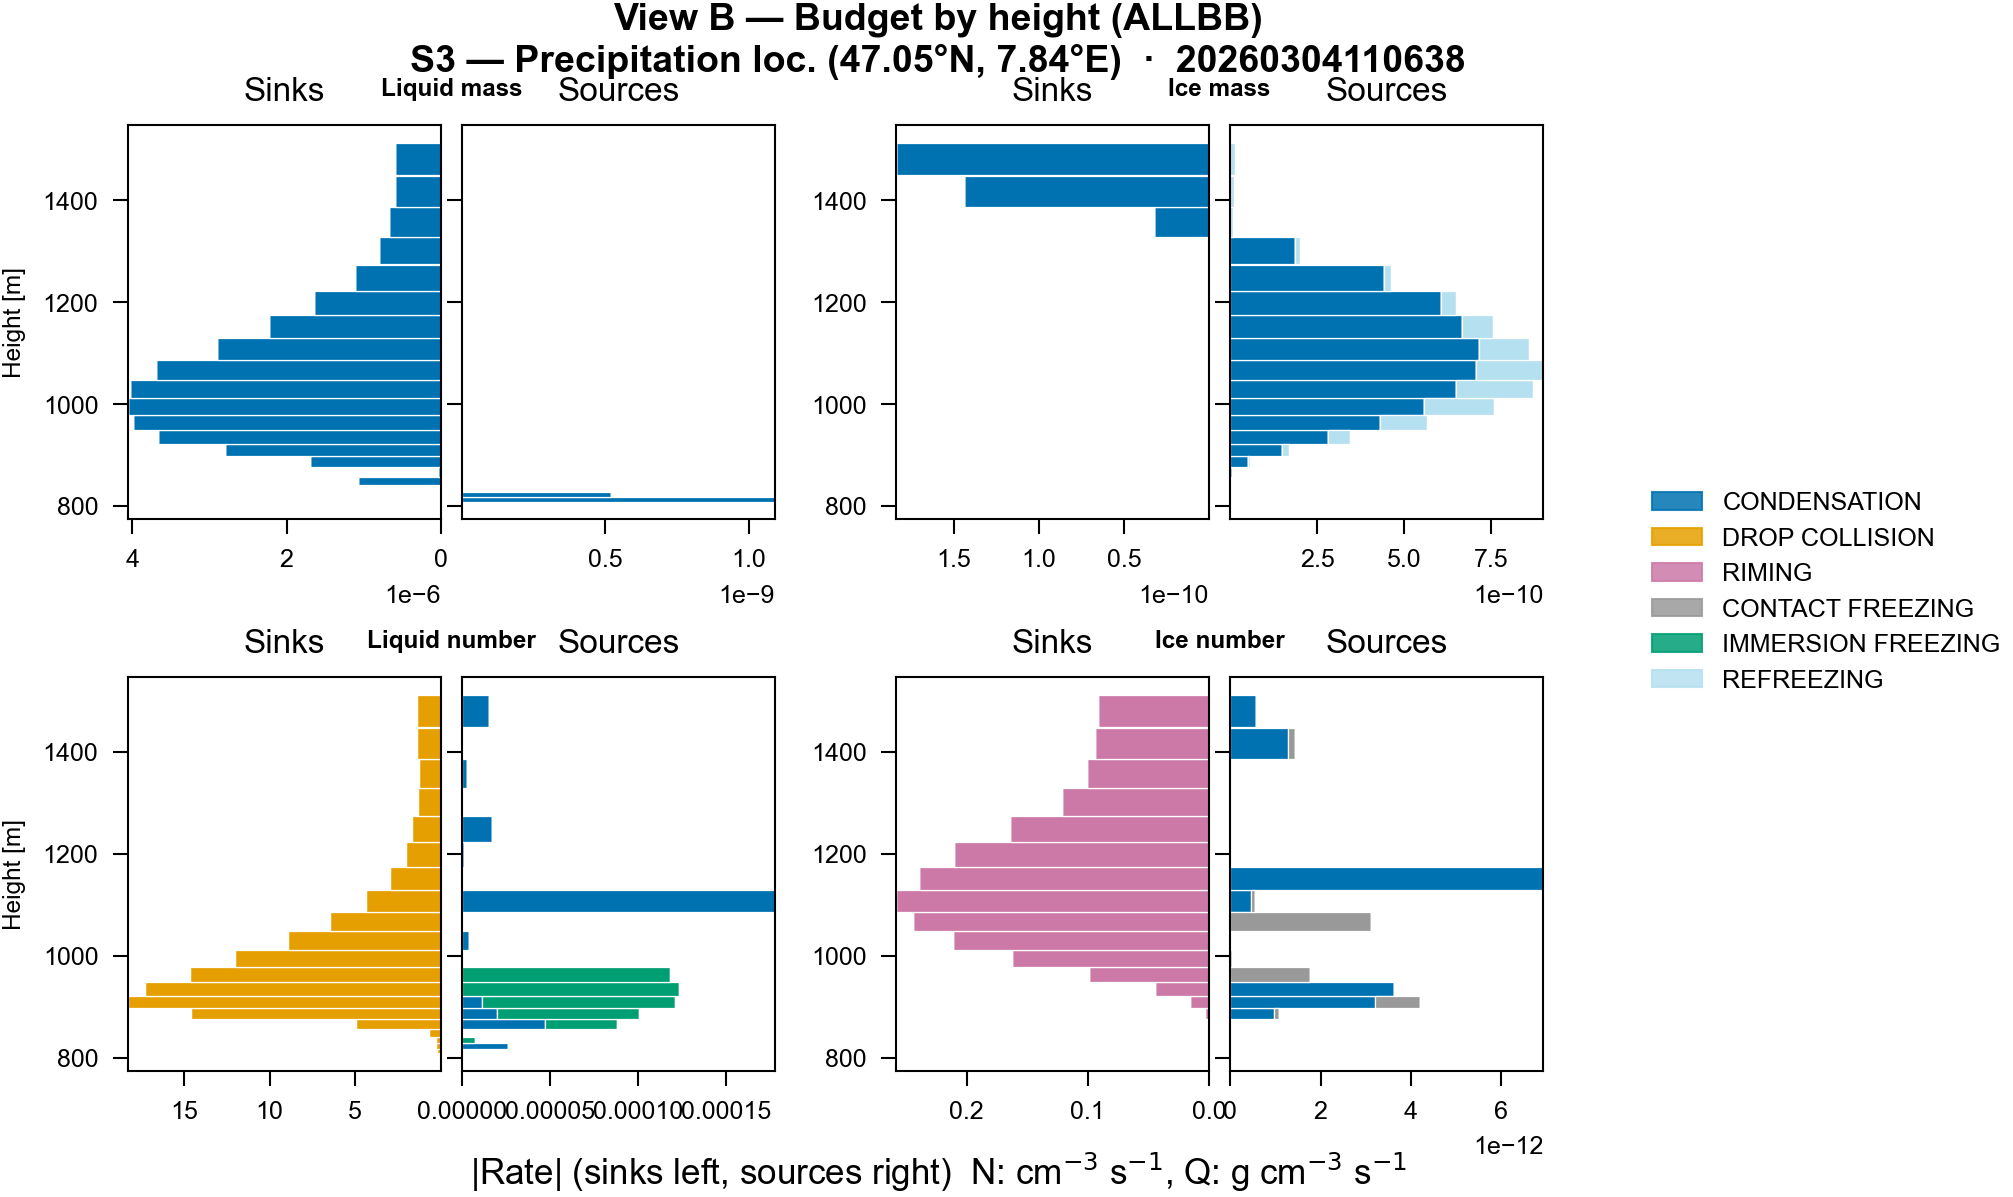

saved → ./stacked_bars_height_liquid_ice_exp1_stn2_ALLBB.png


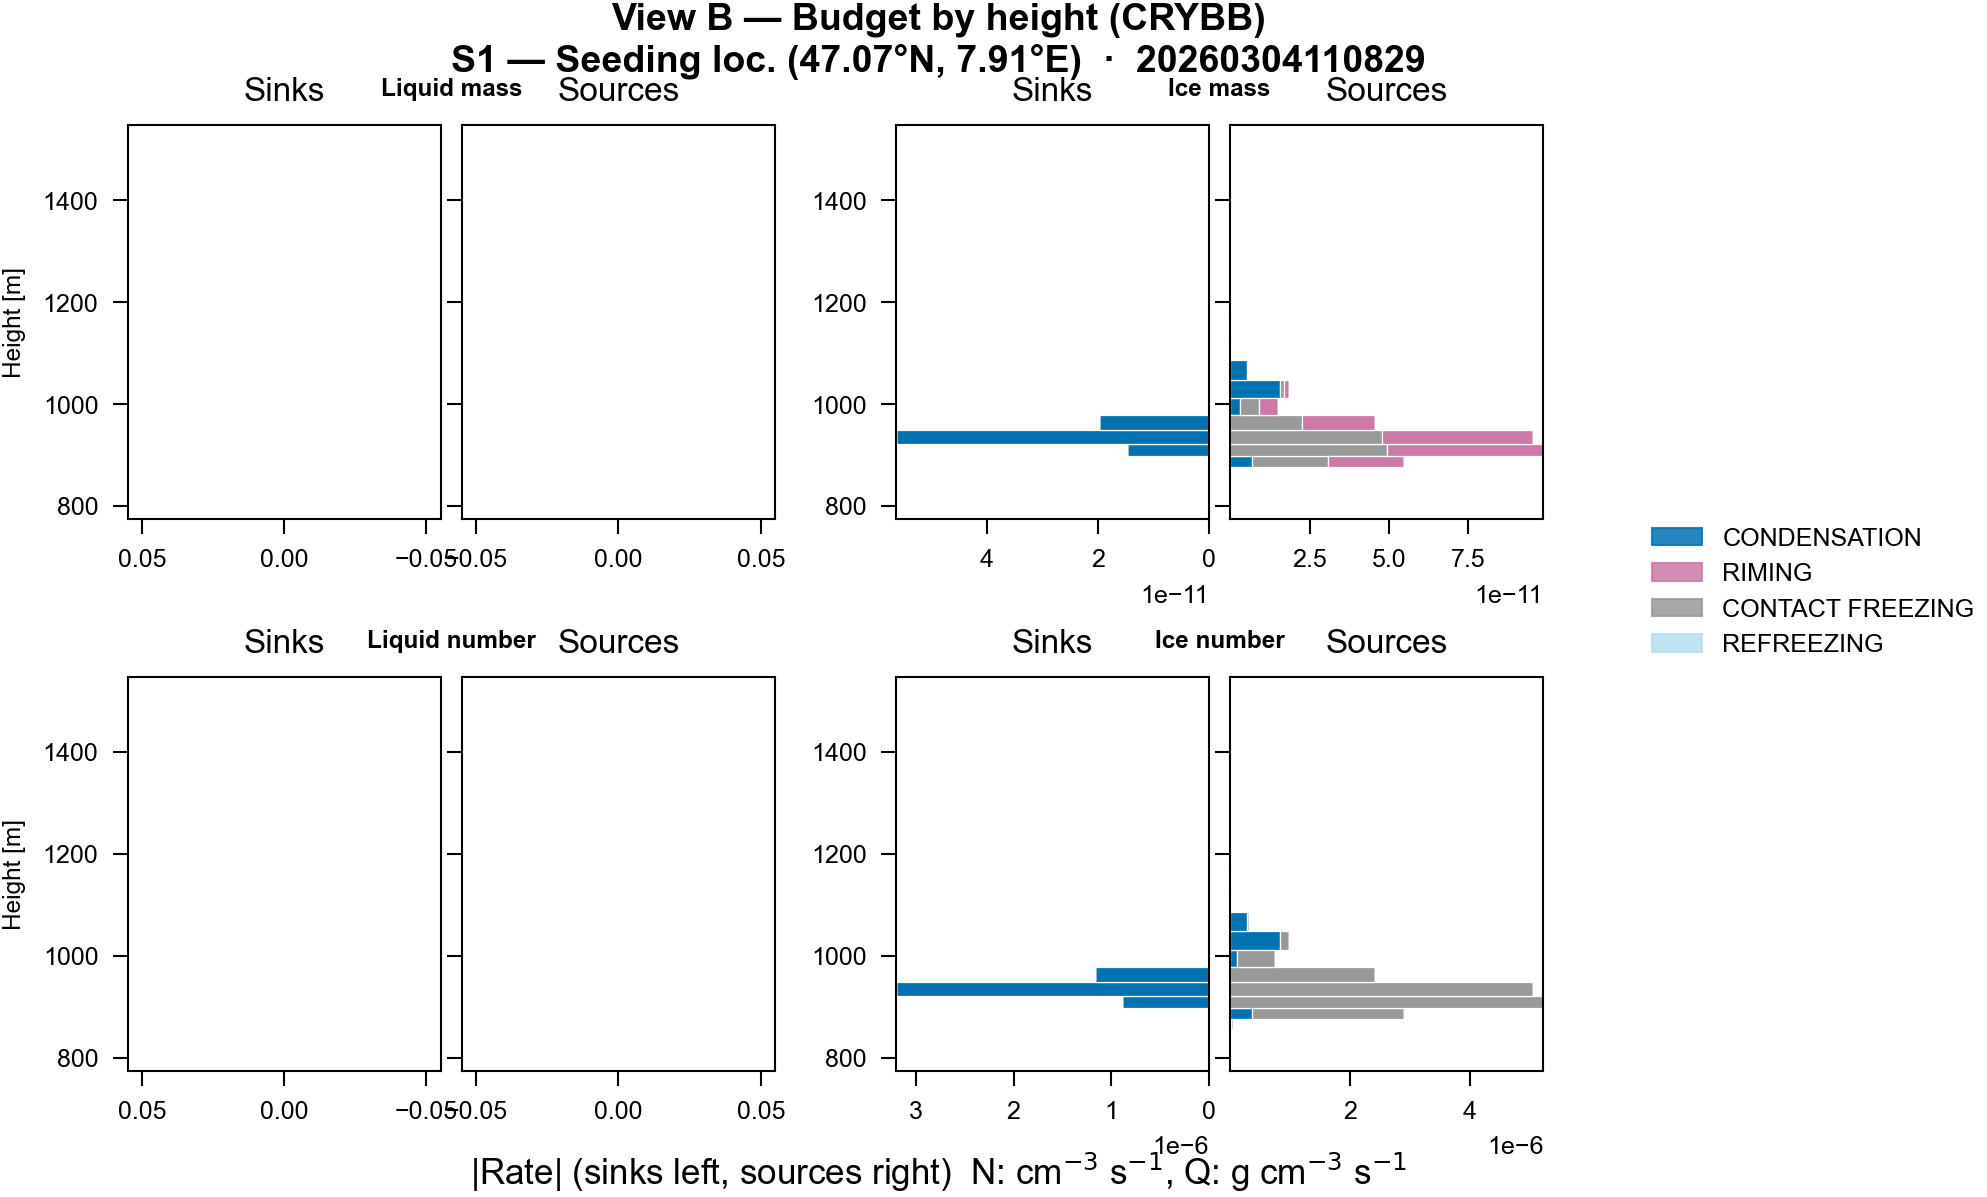

saved → ./stacked_bars_height_liquid_ice_exp2_stn0_CRYBB.png


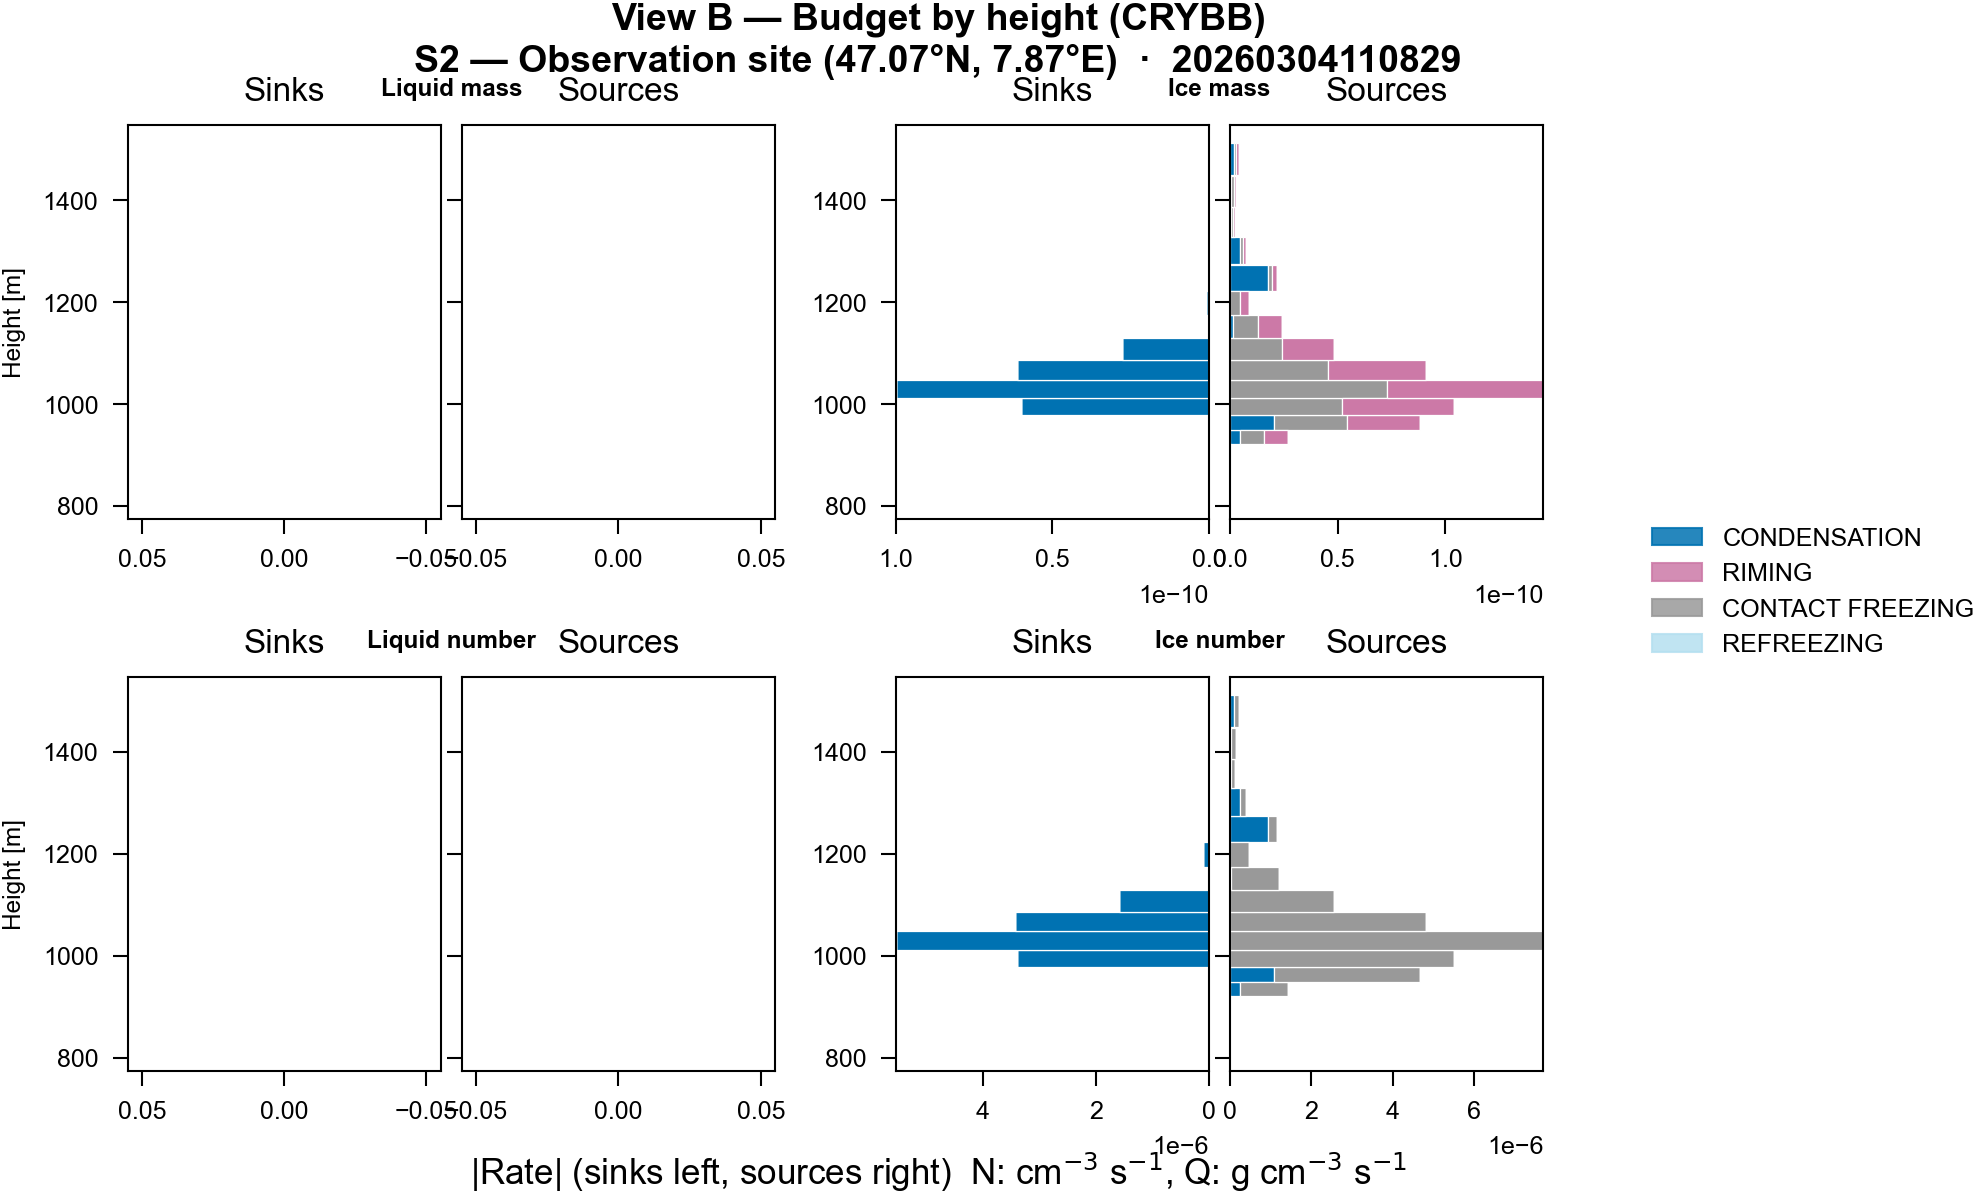

saved → ./stacked_bars_height_liquid_ice_exp2_stn1_CRYBB.png


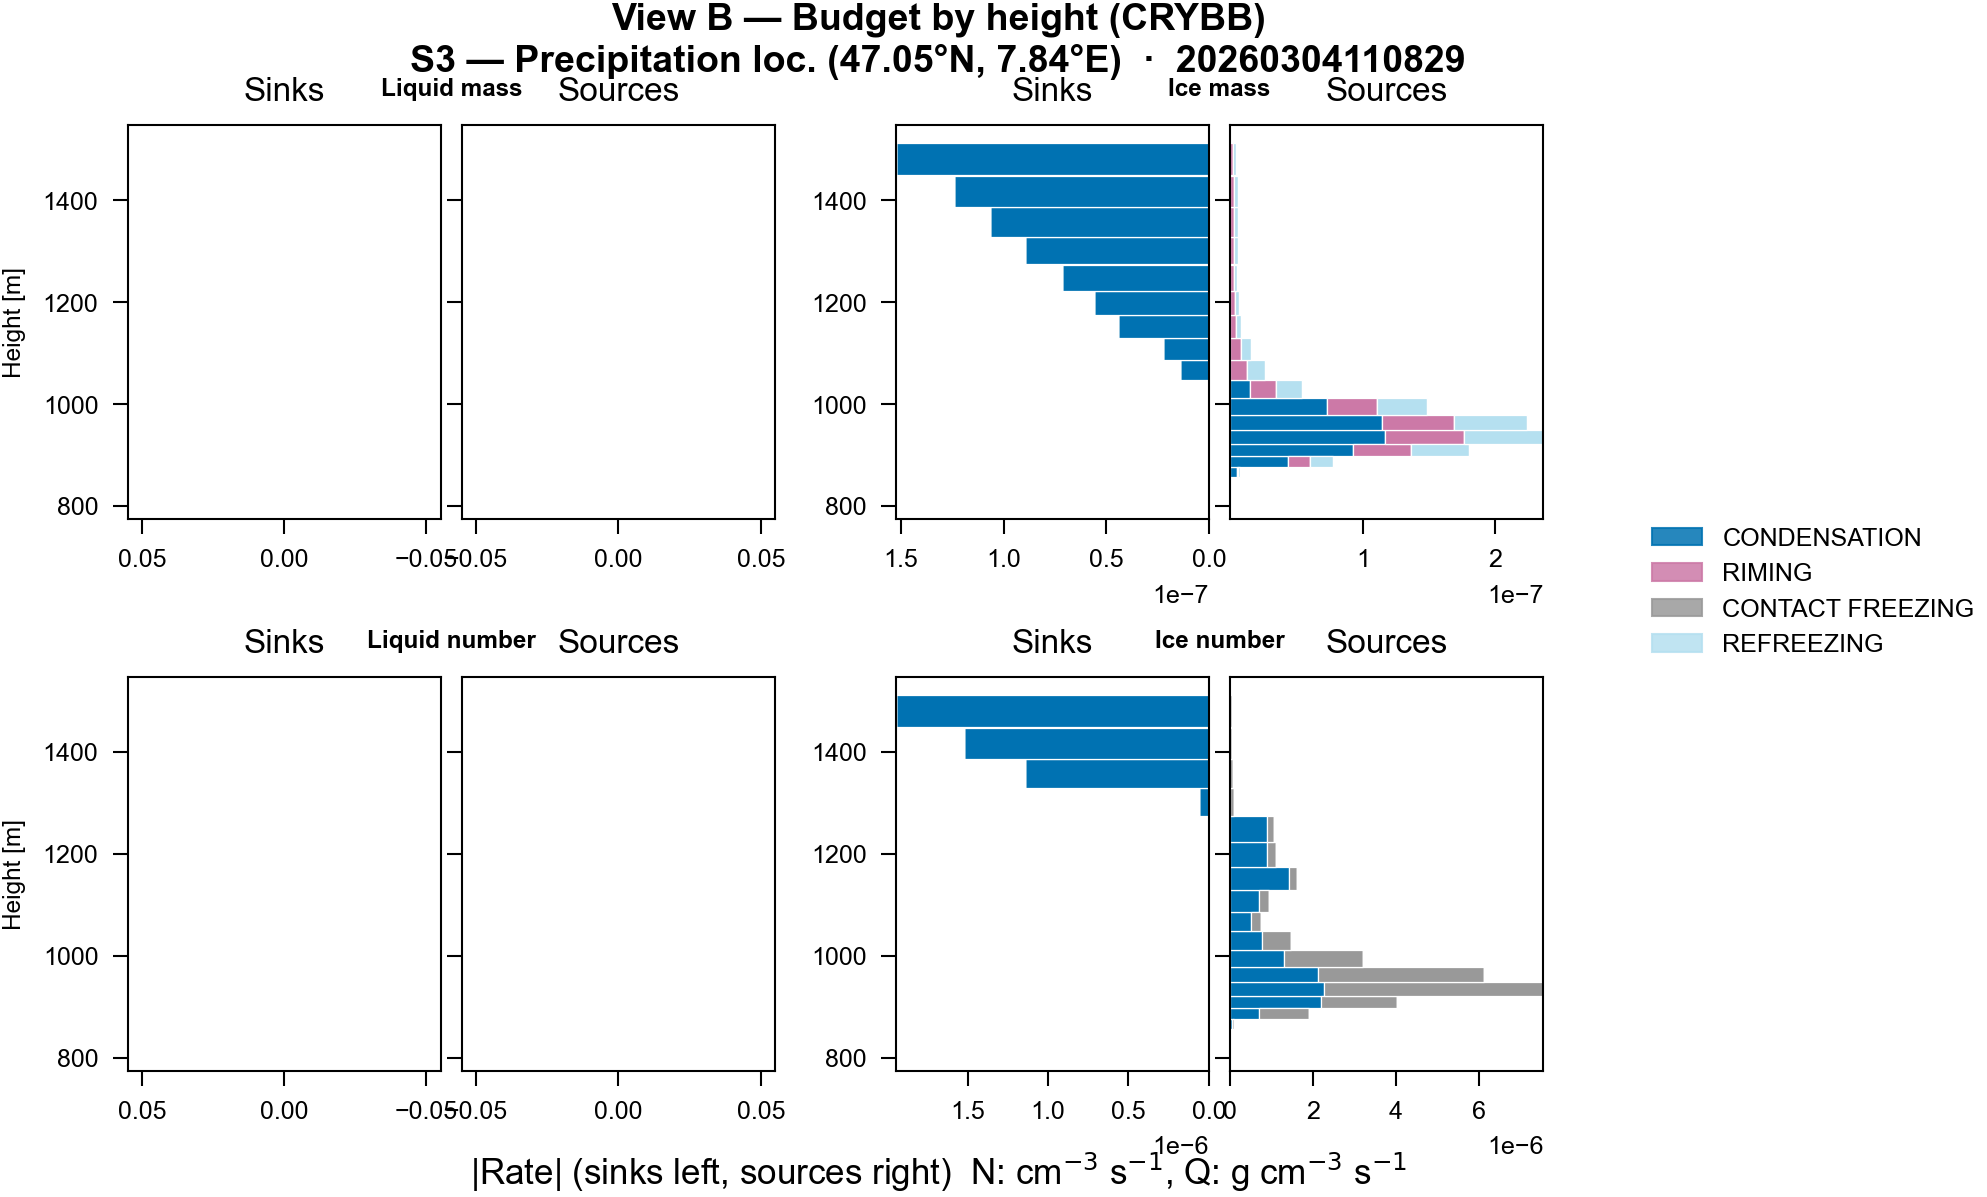

saved → ./stacked_bars_height_liquid_ice_exp2_stn2_CRYBB.png


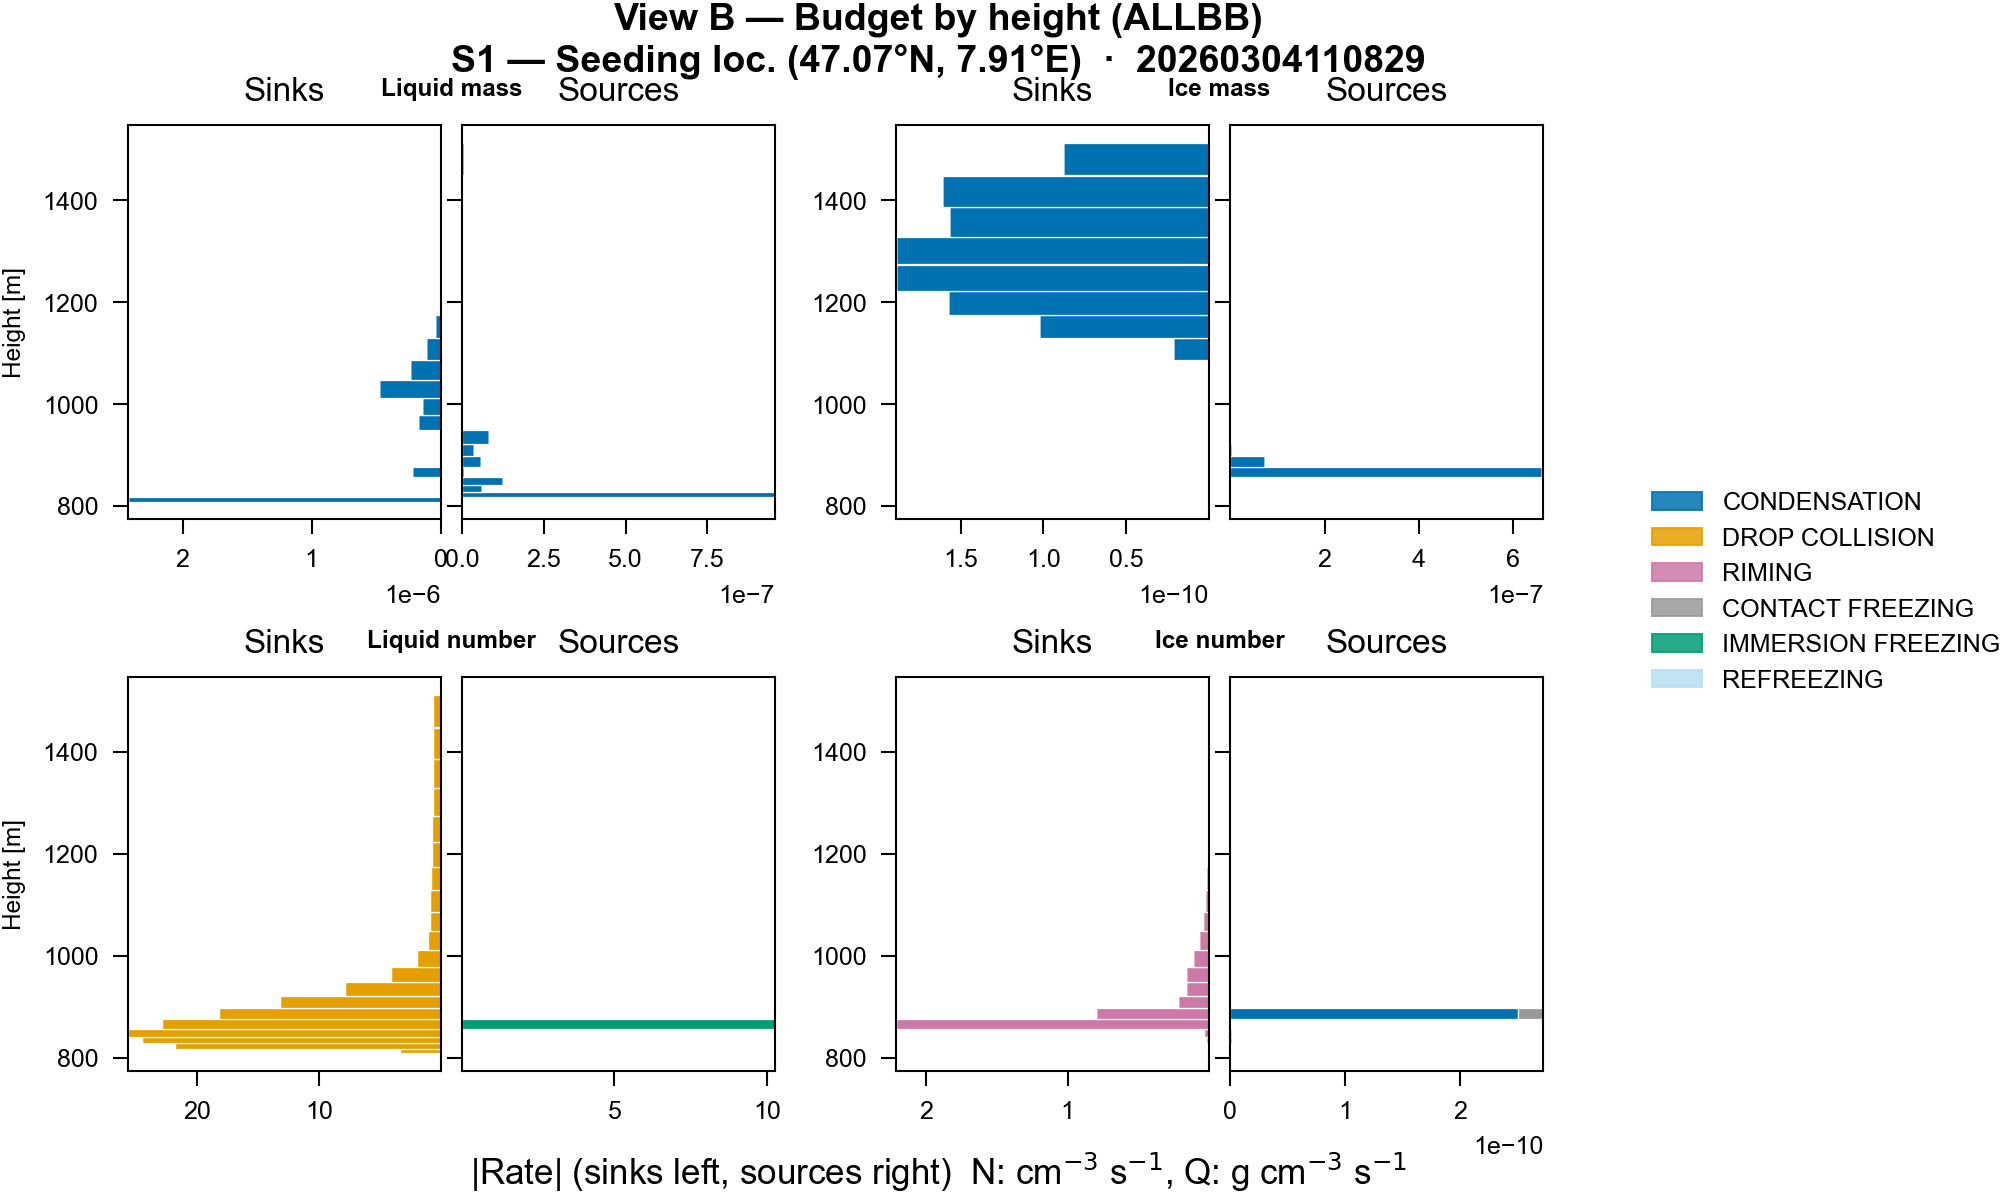

saved → ./stacked_bars_height_liquid_ice_exp2_stn0_ALLBB.png


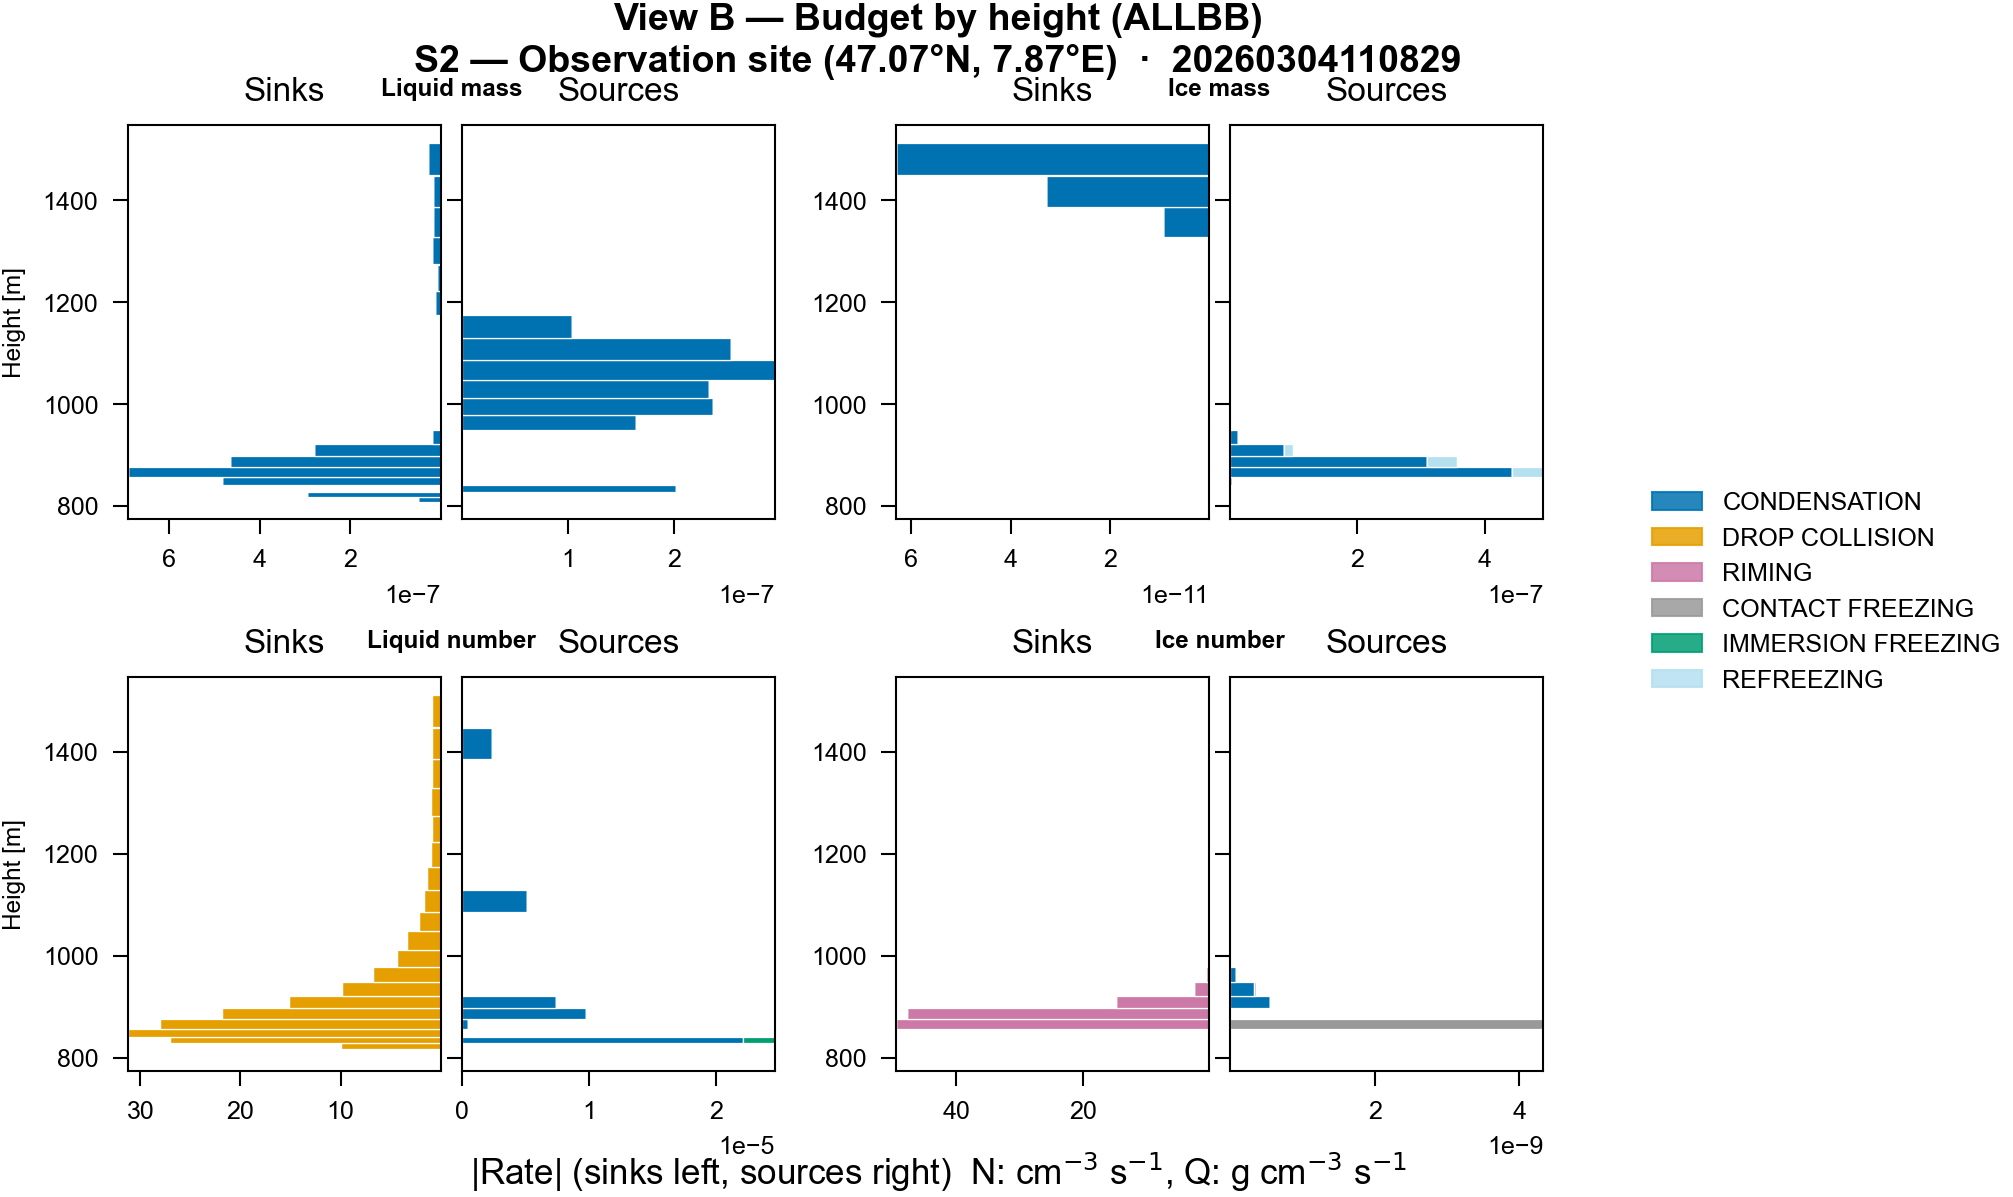

saved → ./stacked_bars_height_liquid_ice_exp2_stn1_ALLBB.png


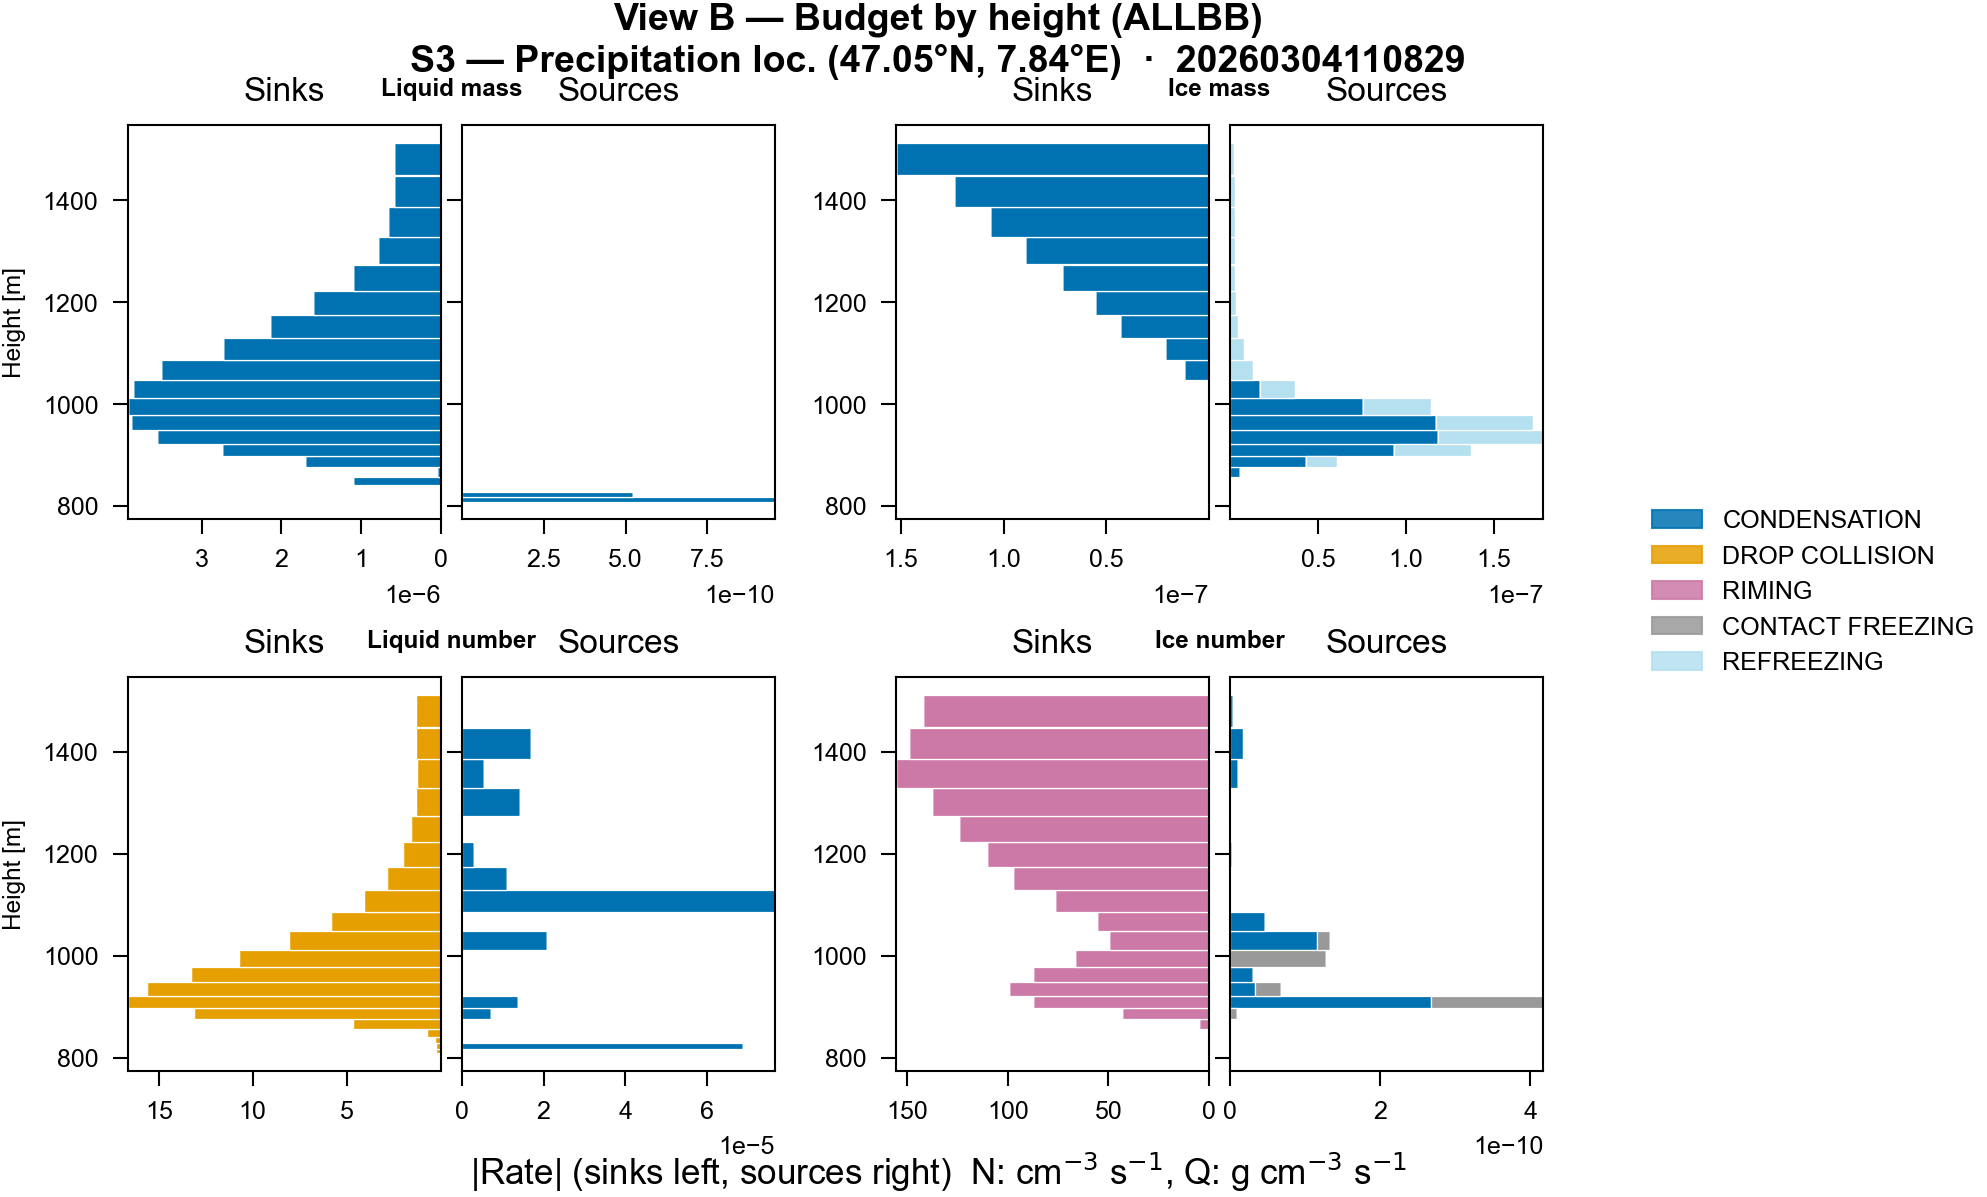

saved → ./stacked_bars_height_liquid_ice_exp2_stn2_ALLBB.png


In [ ]:
def _bars_height_prep(rates_dict, si, bar_fill=0.999):
    """Return (hl, bar_h, pos_vals, neg_vals, procs, colors) for one rates_dict."""
    procs = list(rates_dict.keys())
    colors = [proc_color(p) for p in procs]
    hl = rates_dict[procs[0]].isel(station=si).coords["height_level"].values[::-1]
    hl_s = np.sort(hl)
    if len(hl_s) > 1:
        edges = np.concatenate([
            [hl_s[0] - 0.5 * (hl_s[1] - hl_s[0])],
            0.5 * (hl_s[1:] + hl_s[:-1]),
            [hl_s[-1] + 0.5 * (hl_s[-1] - hl_s[-2])],
        ])
        bar_h = np.diff(edges) * bar_fill
    else:
        bar_h = np.array([20.0])
    pos_vals, neg_vals = {}, {}
    for p in procs:
        da = rates_dict[p].isel(station=si).mean(dim="time").compute()
        v = da.values
        pos_vals[p] = np.where(v > 0, v, 0)
        neg_vals[p] = np.where(v < 0, np.abs(v), 0)
    return hl, bar_h, pos_vals, neg_vals, procs, colors

def plot_stacked_bars_height(rates_dict, unit_label, spectrum_label, si=STN_IDX, range_key=None,
                             bar_fill: float = 0.999):
    """Single spectrum: two panels (sources, sinks). bar_fill: fraction of level bin width."""
    hl, bar_h, pos_vals, neg_vals, procs, colors = _bars_height_prep(rates_dict, si, bar_fill)
    fig, axes = plt.subplots(1, 2, figsize=(FULL_COL_IN, 110 * MM), sharey=True,
                             constrained_layout=True)
    for ax, vals, title in [(axes[0], pos_vals, "Sources (positive)"),
                            (axes[1], neg_vals, "Sinks (|negative|)")]:
        left = np.zeros_like(hl, dtype=float)
        for p, c in zip(procs, colors):
            ax.barh(hl, vals[p], left=left, color=c, label=p,
                    edgecolor="white", linewidth=0.3, height=bar_h)
            left += vals[p]
        ax.set_xlabel(f"|Rate| [{unit_label}]")
        ax.set_title(title)
    axes[0].set_ylabel("Height [m]")
    axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    fig.suptitle(f"View B — {spectrum_label} budget by height [{unit_label}] ({range_key or ACTIVE_RANGE_KEY})\n"
                 f"{stn_label(si)}  (exp {exp_label})", fontweight="semibold")
    plt.show()

def plot_stacked_bars_height_all(rates_N_liq, 
                                 rates_Q_liq, 
                                 rates_N_ice, rates_Q_ice,
                                 si=STN_IDX, 
                                 bar_fill=0.999, legend_position="vertical-right", range_key=None):
    
    """Single figure: 2 rows (mass, number), each row (liquid, ice) side by side.
    Colors from proc_color(PROC_COLORS). legend_position: 'vertical-right' or 'horizontal-bottom'."""
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    row_specs = [
        [(rates_Q_liq, unit_Q, "Liquid mass"), (rates_Q_ice, unit_Q, "Ice mass")],
        [(rates_N_liq, unit_N, "Liquid number"), (rates_N_ice, unit_N, "Ice number")],
    ]
    preps = [
        _bars_height_prep(rates_Q_liq, si, bar_fill),
        _bars_height_prep(rates_Q_ice, si, bar_fill),
        _bars_height_prep(rates_N_liq, si, bar_fill),
        _bars_height_prep(rates_N_ice, si, bar_fill),
    ]
    hl = preps[0][0]
    bar_h = preps[0][1]
    all_procs = set()
    for _, _, _, _, procs, _ in preps:
        all_procs.update(procs)
    procs_ordered = [p for p in PROC_COLORS if p in all_procs]
    active = []
    for p in procs_ordered:
        for k in range(4):
            pos_vals, neg_vals = preps[k][2], preps[k][3]
            if p not in pos_vals:
                continue
            if np.any(pos_vals[p] != 0) or np.any(neg_vals[p] != 0):
                active.append(p)
                break
    procs_ordered = active

    use_constrained = legend_position != "vertical-right"
    fig = plt.figure(figsize=(FULL_COL_IN, min(2 * 52 * MM, MAX_H_IN)))
    gs = gridspec.GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 0.25, 1, 1], height_ratios=[1, 1],
                          hspace=0.4, wspace=0.08)
    axes = np.empty((2, 4), dtype=object)
    for i in range(2):
        axes[i, 0] = fig.add_subplot(gs[i, 0])
        axes[i, 1] = fig.add_subplot(gs[i, 1])
        axes[i, 2] = fig.add_subplot(gs[i, 3])
        axes[i, 3] = fig.add_subplot(gs[i, 4])
    # for i in range(2):
    #     for j in range(4):
    #         axes[i, j].sharey(axes[0, 0])
    prep_idx = 0
    for i, pair in enumerate(row_specs):
        for j, (rates_dict, unit_label, group_title) in enumerate(pair):
            _, _, pos_vals, neg_vals, procs, colors = preps[prep_idx]
            ax_sink = axes[i, 2 * j]
            ax_src = axes[i, 2 * j + 1]
            left = np.zeros_like(hl, dtype=float)
            for p in procs:
                ax_sink.barh(hl, neg_vals[p], left=left, color=proc_color(p), label=p,
                             edgecolor="white", linewidth=0.3, height=bar_h)
                left += neg_vals[p]
            ax_sink.invert_xaxis()
            ax_sink.set_xlabel("")
            ax_sink.set_title("Sinks" if i == 0 and j == 0 else "")
            left = np.zeros_like(hl, dtype=float)
            for p in procs:
                ax_src.barh(hl, pos_vals[p], left=left, color=proc_color(p), label=p,
                            edgecolor="white", linewidth=0.3, height=bar_h)
                left += pos_vals[p]
            ax_src.set_xlabel("")
            ax_src.set_title("Sources" if i == 0 and j == 0 else "")
            prep_idx += 1
    axes[0, 0].set_ylabel("Height [m]", fontsize="small")
    axes[1, 0].set_ylabel("Height [m]", fontsize="small")
    axes[0, 0].set_title("Sinks")
    axes[0, 2].set_title("Sinks")
    axes[1, 0].set_title("Sinks")
    axes[1, 2].set_title("Sinks")
    axes[0, 1].set_title("Sources")
    axes[0, 3].set_title("Sources")
    axes[1, 1].set_title("Sources")
    axes[1, 3].set_title("Sources")
    if legend_position == "vertical-right":
        fig.subplots_adjust(right=0.78)
    fig.canvas.draw_idle()
    for i, pair in enumerate(row_specs):
        for j, (_, _, group_title) in enumerate(pair):
            ax_left = axes[i, 2 * j]
            ax_right = axes[i, 2 * j + 1]
            pos_left = ax_left.get_position()
            pos_right = ax_right.get_position()
            center_x = (pos_left.x0 + pos_right.x1) / 2
            top_y = max(pos_left.y1, pos_right.y1) + 0.02
            fig.text(center_x, top_y, group_title, ha="center", va="bottom", fontsize="small",
                     fontweight="semibold", transform=fig.transFigure)
    handles = [mpatches.Patch(color=proc_color(p), label=p.replace("_", " "), alpha=0.85)
               for p in procs_ordered]
    
    for i, ax in enumerate(axes.flatten()):
        if i % 2 == 1:
            ax.set_yticklabels([])
    if legend_position == "vertical-right":
        fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.82, 0.5),
                   frameon=False, ncol=1)
    else:
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
                   frameon=False, ncol=min(len(procs_ordered), 6))
    fig.supxlabel(f"|Rate| (sinks left, sources right)  N: {unit_N}, Q: {unit_Q}")
    fig.suptitle(f"View B — Budget by height ({range_key or ACTIVE_RANGE_KEY})\n{stn_label(si)}  ·  {exp_label}",
                 fontweight="semibold")
    plt.show()
    return fig, axes

idx_dbg = 1
if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS[:idx_dbg]:
        R = rates_by_exp[eid]
        exp_label = R["exp_label"]
        for range_key in PLOT_RANGE_KEYS:
            Rsel = select_rates_for_range(R, range_key)
            for si in PLOT_STN_IDS[:idx_dbg]:
                fig, ax = plot_stacked_bars_height_all(
                    Rsel["rates_N_liq"], 
                    Rsel["rates_Q_liq"], 
                    Rsel["rates_N_ice"], 
                    Rsel["rates_Q_ice"],
                    si=si, 
                    range_key=range_key
                )
                save_fig(fig, f"stacked_bars_height_liquid_ice_exp{eid}_stn{si}_{range_key}", "png", "./")
